<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Deep Generative Models
</font>
<hr/>
<font color="#800080" size=5>
Assignment 2 : Deep Autoregressive Models
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>
<font face="Times New Roman" size=4>
</font>
<hr>
<font color='red'  size=4>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @ZahraSorkhei, @Ali99os
</font>
<br>
<hr>
</div></font>

### Amir Kooshan Fattah Hesari - 401102191

**You should only change the blank sections, marked with TODO**

Pay attention to docstrings, as they may drastically help with your implementation.

You are advised to read all related papers and material, to help you better understand the design of each model.

# Question 1: Probabilistic Graph Forecasting with Autoregressive Decoders

This note gives a concise introduction to a temporal latent-variable model for **graph sequences** $\{G_t\}_{t=1}^T$ with $G_t=(X_t,A_t)$. It states the model, the training objective (ELBO) in a time-factorized form, the concrete likelihoods used for node features and edges, the effect of a deterministic decoder, and how to generate future graphs.



## Problem setup

We observe a sequence of graph snapshots

$$
G_t = (X_t, A_t), \quad t=1,\dots,T,
$$

where $X_t \in \mathbb{R}^{n \times d}$ stacks node feature vectors $x_t^v$ and $A_t \in \{0,1\}^{n \times n}$ is an undirected adjacency matrix (no self-loops). To capture temporal structure we introduce a latent trajectory

$$
Z_{1:T} = (Z_1, \dots, Z_T), \quad Z_t \in \mathbb{R}^m,
$$

where $Z_t$ is a global latent representation of the whole graph at time $t$.


## Generative (autoregressive latent) model

An autoregressive factorization is used:

$$
p_\theta(X_{1:T}, A_{1:T}, Z_{1:T})
= p(Z_1) \prod_{t=1}^{T-1} p_\theta(Z_{t+1}\mid Z_t)\; p_\theta(X_{t+1}, A_{t+1}\mid Z_t)
$$

Intuition: the latent $Z_t$ summarizes the state at $t$; a transition model $p_\theta(Z_{t+1}\mid Z_t)$ evolves it; conditioned on the current latent we predict the *next* snapshot $(X_{t+1}, A_{t+1})$.

We approximate the true posterior with an amortized encoder (e.g. a GNN+RNN):

$$
q_\phi(Z_t \mid X_{1:t}, A_{1:t}) \quad \text{(often factorized across $t$ for amortization).}
$$


## Variational lower bound (ELBO) — time decomposition

Using the variational approximation

$$
q_\phi(Z_{1:T}\mid X_{1:T},A_{1:T}) = \prod_{t=1}^T q_\phi(Z_t \mid X_{1:t},A_{1:t}),
$$

the marginal log-likelihood admits the ELBO:

$$
\log p_\theta(X_{1:T}, A_{1:T}) \ge
\mathbb{E}_{q_\phi} \Big[ \sum_{t=1}^{T-1} \log p_\theta(X_{t+1}, A_{t+1} \mid Z_t) \Big]
- \mathrm{KL}\big(q_\phi(Z_1 \mid X_1, A_1) \,\|\, p(Z_1)\big)
- \sum_{t=1}^{T-1} \mathbb{E}_{q_\phi} \Big[ \mathrm{KL}\big(q_\phi(Z_{t+1}\mid X_{1:t+1}, A_{1:t+1}) \,\|\, p_\theta(Z_{t+1}\mid Z_t)\big) \Big].
$$

Thus the objective is a sum over time: per-step reconstruction terms plus per-step KL penalties that align the encoder's posterior with the learned transition prior.



## Explicit reconstruction likelihoods

If the decoder factorizes into Gaussian node-features and Bernoulli edges:

- **Node features (per node $v$)**

$$
p_\theta(x_{t+1}^v \mid Z_t) = \mathcal{N}(x_{t+1}^v \mid \mu_\theta^v(Z_t), \Sigma_\theta^v(Z_t)),
$$

hence the feature log-likelihood (for all nodes) is

$$
\log p_\theta(X_{t+1} \mid Z_t)
= -\frac{1}{2} \sum_{v=1}^n \Big[ (x_{t+1}^v - \mu_\theta^v)^\top (\Sigma_\theta^v)^{-1} (x_{t+1}^v - \mu_\theta^v) + \log \det(2 \pi \Sigma_\theta^v) \Big].
$$

(In practice $\Sigma^v$ is taken diagonal or shared for numerical stability.)

- **Edges (for unordered pairs $u<v$)**

$$
p_\theta(A_{t+1} \mid Z_t) = \prod_{u<v} \mathrm{Bernoulli}\big(A_{t+1}^{uv} \mid \pi_\theta^{uv}(Z_t)\big),
$$

so

$$
\log p_\theta(A_{t+1} \mid Z_t) = \sum_{u<v} \Big[ A_{uv} \log \pi_{uv} + (1-A_{uv}) \log (1-\pi_{uv}) \Big].
$$

Combine them:

$$
\log p_\theta(X_{t+1}, A_{t+1} \mid Z_t) = \log p_\theta(X_{t+1} \mid Z_t) + \log p_\theta(A_{t+1} \mid Z_t).
$$


## Deterministic decoder

If the decoder is deterministic (e.g. $X_{t+1}=f_\theta(Z_t)$, $A_{t+1}=g_\theta(Z_t)$ or equivalently Gaussian with vanishing variance), then:

- The likelihood becomes a Dirac (or degenerate Gaussian); log-likelihood is $-\infty$ off the model manifold — numerically unstable.
- Deterministic decoders cannot model multimodality: a single $Z_t$ maps to a single snapshot, so they fail when the conditional distribution is multi-valued.
- Training tends to overfit (model memorizes) or produce poor uncertainty calibration. Probabilistic decoders (non-zero variance, Bernoulli edges) are preferred for stable likelihood-based training and to capture uncertainty/diversity.


## Generating future graphs

Given observed history $X_{1:T}, A_{1:T}$:

1. Infer the posterior at final time: $q_\phi(Z_T \mid X_{1:T}, A_{1:T})$ and sample $z_T \sim q_\phi$ (or use the posterior mean).
2. For $h=1$ to $H$:
   - Sample latent: $z_{T+h} \sim p_\theta(Z_{T+h} \mid z_{T+h-1})$.
   - Sample (or take mean of) snapshot: $(\tilde X_{T+h}, \tilde A_{T+h}) \sim p_\theta(\cdot \mid z_{T+h-1})$ (or use the decoder mean).





In [15]:
import math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

## 1) Synthetic dynamic graph dataset
**Goal:**  
Create dynamic graphs using SBM with Gaussian node features.

**Hints:**  
- `generate_sbm`: adjacency with `p_in` (intra) and `p_out` (inter) edges.  
- `generate_features`: node features from `N(μ_k, Σ_k)` per community.  
- `generate_sequence`: simulate T timesteps with drift and edge flips.  
- `_getitem_` / `_len_`: return sequences.  
- `collate_fn`: batch multiple sequences.

**Output:**  
- `X_seq`: `[T, n_nodes, feat_dim]`  
- `A_seq`: `[T, n_nodes, n_nodes]`

In [31]:
class SyntheticGraphDataset(Dataset):
    """
    Generate synthetic evolving graphs.
    - Each sequence has T snapshots.
    - Node features: random walk.
    - Edges: flip with small probability.
    """

    def __init__(self, n_nodes=30, feat_dim=4, T=30, n_seq=200, p_flip=0.01):
        super().__init__()

        self.n_nodes = n_nodes
        self.feat_dim = feat_dim
        self.T = T
        self.n_seq = n_seq
        self.p_flip = p_flip

        # Pre-generate all sequences and store them
        self.data = [self.generate_sequence() for _ in range(n_seq)]

    def generate_sequence(self):
        """
        Create a single temporal graph sequence:
          - Initial snapshot from a 3-community SBM.
          - Node features from community-dependent Gaussians.
          - Features follow a random walk over time.
          - Edges are flipped independently with prob p_flip.
        """
        n_comm = 3
        nodes_per_comm = self.n_nodes // n_comm

        # --- SBM probabilities (3 communities) ---
        p_in = 0.4
        p_out = 0.05
        prob_matrix = torch.zeros(self.n_nodes, self.n_nodes)

        for i in range(self.n_nodes):
            for j in range(self.n_nodes):
                same_comm = (i // nodes_per_comm) == (j // nodes_per_comm)
                prob_matrix[i, j] = p_in if same_comm else p_out

        # Sample initial adjacency and make it undirected, no self-loops
        A0 = torch.bernoulli(prob_matrix)
        A0 = torch.triu(A0, diagonal=1)
        A0 = A0 + A0.t()

        # --- Initial node features ---
        X0 = torch.zeros(self.n_nodes, self.feat_dim)
        mu_scale = 1.5
        for i in range(self.n_nodes):
            # First community has positive mean, others negative
            mu = mu_scale if (i // nodes_per_comm) == 0 else -mu_scale
            X0[i] = torch.normal(mean=mu, std=0.3, size=(self.feat_dim,))

        # Containers for the temporal sequence
        X_seq = [X0]
        A_seq = [A0]

        X_curr = X0
        A_curr = A0

        # --- Temporal evolution ---
        for _ in range(1, self.T):
            # Feature random walk
            noise = torch.randn_like(X_curr) * 0.05
            X_next = X_curr + noise

            # Edge flips
            flip_mask = torch.bernoulli(
                torch.full((self.n_nodes, self.n_nodes), self.p_flip)
            )
            flip_mask = torch.triu(flip_mask, diagonal=1)
            flip_mask = flip_mask + flip_mask.t()

            A_next = torch.abs(A_curr - flip_mask)
            A_next.fill_diagonal_(0)

            X_seq.append(X_next)
            A_seq.append(A_next)

            X_curr = X_next
            A_curr = A_next

        # Shapes:
        #   X_seq: [T, n_nodes, feat_dim]
        #   A_seq: [T, n_nodes, n_nodes]
        return torch.stack(X_seq), torch.stack(A_seq)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # returns (X_seq, A_seq)
        return self.data[idx]


def collate_fn(batch):
    """
    Collate function for a batch of sequences.

    Input:
        batch: list of (X_seq, A_seq)
            - X_seq: [T, n_nodes, feat_dim]
            - A_seq: [T, n_nodes, n_nodes]

    Output:
        X_batch: [B, T, n_nodes, feat_dim]
        A_batch: [B, T, n_nodes, n_nodes]
    """
    X_list, A_list = zip(*batch)
    X_batch = torch.stack(X_list, dim=0)
    A_batch = torch.stack(A_list, dim=0)
    return X_batch, A_batch


## 2) Encoder, Prior, Decoder

### SimpleGraphEncoder
Aggregates node features and degree statistics.  
Computes graph-level latent embeddings `mu` and `logvar` for VAE.  
No external graph libraries required; uses only PyTorch.

### TransitionPrior
Models the latent temporal evolution `p(Z_{t+1} | Z_t)` as a Gaussian.  
Produces mean and variance for autoregressive sampling in VAE.

### Decoder
Reconstructs node features and adjacency matrices from latent `Z_t`.  
Uses node embeddings combined with latent vectors for feature decoding.  
Produces edge logits for Bernoulli reconstruction of adjacency.  
Supports probabilistic reconstruction via Gaussian features + Bernoulli edges.

In [33]:

class SimpleGraphEncoder(nn.Module):
    """
    Simple encoder that aggregates node features and degree statistics.
    Uses a small GCN-style stack with residual connections to produce
    graph-level latent mean and log-variance.
    """

    def __init__(self, n_nodes, feat_dim, hidden_dim, latent_dim):
        super().__init__()

        self.n_nodes = n_nodes

        # Node-wise feature encoder (features + degree)
        self.feat_encoder = nn.Linear(feat_dim + 1, hidden_dim)

        # GCN-style layers (implemented as Linear after A_norm @ H)
        self.gcn1 = nn.Linear(hidden_dim, hidden_dim)
        self.gcn2 = nn.Linear(hidden_dim, hidden_dim)
        self.gcn3 = nn.Linear(hidden_dim, hidden_dim)

        # Graph-level projection to latent params
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.act = nn.LeakyReLU(0.1)

    def _gcn_block(self, h, a_norm, layer):
        """
        Single residual GCN block:
            h' = act(layer(A_norm @ h)) + h
        """
        h_res = h
        h = torch.bmm(a_norm, h)
        h = layer(h)
        h = self.act(h)
        return h + h_res

    def forward(self, x, a):
        """
        Args:
            x : [B, N, F]  node features
            a : [B, N, N]  adjacency (0/1), no self-loops

        Returns:
            mu     : [B, latent_dim]
            logvar : [B, latent_dim]
        """
        # --- augment features with (normalized) degree ---
        deg = a.sum(dim=-1, keepdim=True)          # [B, N, 1]
        deg = deg / float(self.n_nodes)
        x_aug = torch.cat([x, deg], dim=-1)        # [B, N, F+1]

        # initial node embedding
        h = self.act(self.feat_encoder(x_aug))     # [B, N, H]

        # --- adjacency normalization with self-loops ---
        a_self = a + torch.eye(self.n_nodes, device=x.device).unsqueeze(0)  # [B, N, N]
        d_inv = 1.0 / (a_self.sum(dim=-1, keepdim=True) + 1e-6)             # [B, N, 1]
        a_norm = a_self * d_inv                                              # row-normalized

        # --- three residual GCN blocks ---
        h = self._gcn_block(h, a_norm, self.gcn1)
        h = self._gcn_block(h, a_norm, self.gcn2)
        h = self._gcn_block(h, a_norm, self.gcn3)

        # --- graph pooling (mean) ---
        h_g = h.mean(dim=1)                          # [B, H]

        # latent parameters
        mu = self.fc_mu(h_g)                         # [B, latent_dim]
        logvar = self.fc_logvar(h_g)                 # [B, latent_dim]
        return mu, logvar


class TransitionPrior(nn.Module):
    """ Gaussian transition prior p(Z_{t+1} | Z_t). """

    def __init__(self, latent_dim, hidden_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z_t):
        """
        Args:
            z_t : [B, latent_dim]

        Returns:
            mu     : [B, latent_dim]  (shifted by z_t, as in original code)
            logvar : [B, latent_dim]
        """
        h = self.net(z_t)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        # same behavior: mean is residual around z_t
        return mu + z_t, logvar


class Decoder(nn.Module):
    """ Decode node features and edges from latent Z_t. """

    def __init__(self, n_nodes, feat_dim, latent_dim, hidden_dim):
        super().__init__()

        self.n_nodes = n_nodes

        # Learnable node embeddings (shared across batch)
        self.node_emb = nn.Parameter(
            torch.randn(1, n_nodes, hidden_dim) * 0.1
        )

        # Project latent z to node-hidden space
        self.z_proj = nn.Linear(latent_dim, hidden_dim)

        # Node decoder network
        self.decoder_net = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
        )

        # Heads for node feature distribution
        self.feat_mu_head = nn.Linear(hidden_dim, feat_dim)
        self.feat_logvar_head = nn.Linear(hidden_dim, feat_dim)

        # Projection used to form edge logits via inner product
        self.edge_proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, z_t):
        """
        Args:
            z_t : [B, latent_dim]

        Returns:
            x_mu        : [B, N, F]  Gaussian means for node features
            x_logvar    : [B, N, F]  Gaussian log-variances
            adj_logits  : [B, N, N]  Bernoulli logits for adjacency
        """
        batch_size = z_t.size(0)

        # Broadcast latent to nodes
        z_hidden = self.z_proj(z_t)                            # [B, H]
        z_expand = z_hidden.unsqueeze(1).expand(-1, self.n_nodes, -1)  # [B, N, H]

        # Broadcast node embeddings to batch
        node_expand = self.node_emb.expand(batch_size, -1, -1)        # [B, N, H]

        # Concatenate and decode node representations
        combined = torch.cat([z_expand, node_expand], dim=-1)         # [B, N, 2H]
        h = self.decoder_net(combined)                                # [B, N, H]

        # Node feature distribution
        x_mu = self.feat_mu_head(h)                                   # [B, N, F]
        x_logvar = self.feat_logvar_head(h)                           # [B, N, F]

        # Edge logits via projected inner product
        h_edge = self.edge_proj(h)                                    # [B, N, H]
        adj_logits = torch.bmm(h_edge, h_edge.transpose(1, 2))        # [B, N, N]

        # Mask self-loops with very negative logits
        eye = torch.eye(self.n_nodes, device=adj_logits.device)
        eye = eye.unsqueeze(0).expand(batch_size, -1, -1)             # [B, N, N]
        adj_logits = adj_logits.masked_fill(eye.bool(), -1e9)

        return x_mu, x_logvar, adj_logits


`reparameterize`: samples latent variable using the reparameterization trick.  
`kl_gauss`: closed-form KL divergence between two Gaussians.  
`nll_gaussian`: negative log-likelihood for node features.  
`nll_bernoulli`: negative log-likelihood (binary cross-entropy) for edges.

In [34]:
def reparameterize(mu, logvar):
    """
    Reparameterization trick:
        z = mu + std * eps,   eps ~ N(0, I)

    Args:
        mu     : tensor of means
        logvar : tensor of log-variances

    Returns:
        z      : sampled tensor with same shape as mu/logvar
    """
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


def kl_gauss(mu_q, logvar_q, mu_p, logvar_p):
    """
    Closed-form KL divergence KL(q || p) for diagonal Gaussians.

    q = N(mu_q, diag(exp(logvar_q)))
    p = N(mu_p, diag(exp(logvar_p)))

    Returns:
        Scalar KL value (summed over all dimensions and batch).
    """
    # Clamp log-variances for numerical stability
    logvar_q = torch.clamp(logvar_q, -10.0, 10.0)
    logvar_p = torch.clamp(logvar_p, -10.0, 10.0)

    var_q = torch.exp(logvar_q)
    var_p = torch.exp(logvar_p)
    diff = mu_q - mu_p

    kl_element = (
        logvar_p - logvar_q - 1.0 +
        (var_q + diff.pow(2)) / var_p
    )

    # Sum over all entries (same behavior as original)
    return 0.5 * torch.sum(kl_element)


def nll_gaussian(x, mu, logvar):
    """
    Negative log-likelihood under a diagonal Gaussian:
        N(x | mu, diag(exp(logvar)))

    Returns:
        Scalar NLL (summed over batch and all dimensions).
    """
    # Clamp log-variances for stability
    logvar = torch.clamp(logvar, -10.0, 10.0)

    var = torch.exp(logvar)
    # log(2π) from numpy (same as original)
    log_2pi = np.log(2.0 * np.pi)

    # Elementwise NLL
    loss = 0.5 * (
        log_2pi + logvar + (x - mu).pow(2) / var
    )

    # Sum over everything (batch + dims)
    return torch.sum(loss)


def nll_bernoulli(logits, target):
    """
    Negative log-likelihood for Bernoulli variables with logits.

    Args:
        logits : raw logits for Bernoulli probabilities
        target : binary targets (0/1)

    Returns:
        Scalar BCE loss (summed over batch and all dimensions).
    """
    return F.binary_cross_entropy_with_logits(
        logits, target, reduction="sum"
    )


## 4) TemporalGraphVAE
Define the Temporal Graph VAE model.  
- Encode node features & adjacency into latent `z`.  
- Model transitions `p(z_{t+1}|z_t)`.  
- Decode `z` to reconstruct node features and edges.  
- Compute ELBO (reconstruction + KL) for training.

In [35]:
class TemporalGraphVAE(nn.Module):
    """
    Temporal Graph VAE:
    - Encodes each graph snapshot (X_t, A_t) into a latent z_t.
    - Uses a Gaussian transition prior p(z_{t+1} | z_t).
    - Decodes z_t to predict (X_{t+1}, A_{t+1}).
    - Optimizes an ELBO: reconstruction + KL terms over time.
    """

    def __init__(self, n_nodes, feat_dim, z_dim=16):
        super().__init__()

        hidden_dim = 256

        self.encoder = SimpleGraphEncoder(
            n_nodes=n_nodes,
            feat_dim=feat_dim,
            hidden_dim=hidden_dim,
            latent_dim=z_dim,
        )
        self.transition = TransitionPrior(
            latent_dim=z_dim,
            hidden_dim=hidden_dim,
        )
        self.decoder = Decoder(
            n_nodes=n_nodes,
            feat_dim=feat_dim,
            latent_dim=z_dim,
            hidden_dim=hidden_dim,
        )

        self.z_dim = z_dim

    def forward(self, X_seq, A_seq, kl_weight=1.0):
        """
        Args:
            X_seq : [B, T, N, F]  node features over time
            A_seq : [B, T, N, N]  adjacencies over time
            kl_weight : scalar multiplier on KL (beta-VAE style)

        Returns:
            loss        : scalar total loss (mean over batch)
            recon_loss  : scalar reconstruction part (mean over batch)
            kl_loss     : scalar KL part (mean over batch)
        """
        B, T, N, F = X_seq.shape

        kl_loss = 0
        recon_loss = 0
        z_prev = None

        for t in range(T):
            # Current snapshot
            x_t = X_seq[:, t, :, :]   # [B, N, F]
            a_t = A_seq[:, t, :, :]   # [B, N, N]

            # Posterior q(z_t | x_t, a_t)
            mu_q, logvar_q = self.encoder(x_t, a_t)   # [B, z_dim] each
            z_t = reparameterize(mu_q, logvar_q)      # [B, z_dim]

            # Prior p(z_t):
            #   - for t=0: standard normal N(0, I)
            #   - for t>0: transition prior p(z_t | z_{t-1})
            if t == 0:
                mu_p = torch.zeros_like(mu_q)
                logvar_p = torch.zeros_like(logvar_q)
            else:
                mu_p, logvar_p = self.transition(z_prev)

            # KL(q(z_t) || p(z_t))
            kl_loss += kl_gauss(mu_q, logvar_q, mu_p, logvar_p)

            # Reconstruction term: use z_t to predict (x_{t+1}, a_{t+1})
            if t < T - 1:
                x_next_gt = X_seq[:, t + 1, :, :]   # [B, N, F]
                a_next_gt = A_seq[:, t + 1, :, :]   # [B, N, N]

                x_mu, x_logvar, a_logits = self.decoder(z_t)

                loss_x = nll_gaussian(x_next_gt, x_mu, x_logvar)
                loss_a = nll_bernoulli(a_logits, a_next_gt)
                recon_loss += (loss_x + loss_a)

            # Carry latent forward in time for transition prior
            z_prev = z_t

        # Normalize by batch size (same as original)
        total_loss = (recon_loss + kl_weight * kl_loss) / B
        return total_loss, recon_loss / B, kl_loss / B


## 5) Visualization helpers

In [36]:
def visualize_graphs(A_true, A_recon_probs, communities, epoch, K, p_in, p_out):
    A_recon_bin = (A_recon_probs >= 0.5).astype(int)
    G_true, G_recon = nx.from_numpy_array(A_true), nx.from_numpy_array(A_recon_bin)
    pos = nx.spring_layout(G_true, seed=42)
    plt.figure(figsize=(9, 4))
    plt.suptitle(f"SBM Graphs (Epoch {epoch})\n"
                 f"K={K}, Intra={p_in}, Inter={p_out}\n"
                 f"In each component: X~N(μ_k, Σ_k)", fontsize=10)
    plt.subplot(1, 2, 1)
    nx.draw(G_true, pos, node_color=communities, cmap='tab10', node_size=100, with_labels=False, alpha=0.8)
    plt.title("True graph")
    plt.subplot(1, 2, 2)
    nx.draw(G_recon, pos, node_color=communities, cmap='tab10', node_size=100, with_labels=False, alpha=0.8)
    plt.title("Reconstructed (p≥0.5)")
    plt.tight_layout()
    plt.show()


## 6) Training
Train the Temporal Graph VAE.  
- Loop over epochs and batches.  
- Forward pass, compute loss, backprop, optimizer step.  
- Track and print losses (`Total`, `Recon`, `KL`).  
- Optionally visualize true vs reconstructed graphs every `vis_interval`.

In [38]:

def train_model(vis_interval=10, epochs=100):
    """
    Train the TemporalGraphVAE on the synthetic SBM-based dynamic graph dataset.

    - Uses KL warmup up to 0.1.
    - Logs total / recon / KL losses per epoch.
    - Every `vis_interval` epochs, visualizes true vs reconstructed graph
      at a fixed time step using `visualize_graphs`.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ----------------------------------------------------------------------
    # Dataset & DataLoader
    # ----------------------------------------------------------------------
    dataset = SyntheticGraphDataset(
        n_nodes=30,
        feat_dim=4,
        T=30,
        n_seq=200,
        p_flip=0.005,
    )
    dataloader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=True,
        collate_fn=collate_fn,
    )

    # ----------------------------------------------------------------------
    # Model & optimizer
    # ----------------------------------------------------------------------
    model = TemporalGraphVAE(
        n_nodes=30,
        feat_dim=4,
        z_dim=32,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Fixed community labels for visualization (2-block split)
    communities = np.concatenate(
        [np.zeros(15), np.ones(15)]
    ).astype(int)

    # ----------------------------------------------------------------------
    # Training loop
    # ----------------------------------------------------------------------
    for epoch in range(1, epochs + 1):
        model.train()

        total_loss_epoch = 0.0
        total_recon_epoch = 0.0
        total_kl_epoch = 0.0

        # Linear KL warmup up to 0.1
        kl_weight = min(0.1, epoch * 0.002)

        for batch_idx, (X_seq, A_seq) in enumerate(dataloader):
            X_seq = X_seq.to(device)   # [B, T, N, F]
            A_seq = A_seq.to(device)   # [B, T, N, N]

            optimizer.zero_grad()

            loss, recon, kl = model(
                X_seq,
                A_seq,
                kl_weight=kl_weight,
            )

            # Skip NaN batches if they occur
            if torch.isnan(loss):
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss_epoch += loss.item()
            total_recon_epoch += recon.item()
            total_kl_epoch += kl.item()

        # Epoch averages
        avg_loss = total_loss_epoch / len(dataloader)
        avg_recon = total_recon_epoch / len(dataloader)
        avg_kl = total_kl_epoch / len(dataloader)

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {avg_loss:.2f} | "
            f"Recon: {avg_recon:.2f} | "
            f"KL: {avg_kl:.2f} | "
            f"kl_w: {kl_weight:.4f}"
        )

        # ------------------------------------------------------------------
        # Visualization (every vis_interval epochs)
        # ------------------------------------------------------------------
        if epoch % vis_interval == 0:
            model.eval()
            with torch.no_grad():
                # Take the first sequence from the dataset
                X_sample, A_sample = dataset[0]          # X:[T,N,F], A:[T,N,N]
                X_sample = X_sample.unsqueeze(0).to(device)  # [1, T, N, F]
                A_sample = A_sample.unsqueeze(0).to(device)  # [1, T, N, N]

                # Choose a time index t and predict t+1
                t = 15
                x_t = X_sample[:, t, :, :]               # [1, N, F]
                a_t = A_sample[:, t, :, :]               # [1, N, N]

                # Ground-truth future adjacency
                a_target = A_sample[:, t + 1, :, :]      # [1, N, N]
                a_target = a_target.squeeze(0).cpu().numpy()

                # Encode -> sample -> decode
                mu, logvar = model.encoder(x_t, a_t)
                z = reparameterize(mu, logvar)
                _, _, adj_logits = model.decoder(z)

                probs = torch.sigmoid(adj_logits)
                probs = probs.squeeze(0).cpu().numpy()   # [N, N]

                # Use your visualization helper
                visualize_graphs(
                    A_true=a_target,
                    A_recon_probs=probs,
                    communities=communities,
                    epoch=epoch,
                    K=3,
                    p_in=0.6,
                    p_out=0.05,
                )
    
    return model, dataset


## 7) Testing
Evaluate the trained model on sample sequences.  
- Encode last snapshot, decode to get reconstructed adjacency/features.  
- Compute simple metrics (e.g., edge accuracy).  
- Visualize true vs reconstructed graphs for verification.

In [39]:
def test_model(model, dataset):
    """
    Evaluate a trained TemporalGraphVAE on a subset of the dataset.

    - Loads weights from 'temporal_graph_vae_sbm.pth'.
    - For 10 sequences, uses the second-to-last snapshot (T-2) to
      reconstruct the last snapshot (T-1).
    - Computes simple edge-wise accuracy.
    - For the first sample, visualizes true vs reconstructed graphs.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    total_acc = 0.0
    count = 0

    # Fixed 2-block community assignment for visualization
    communities = np.concatenate(
        [np.zeros(15), np.ones(15)]
    ).astype(int)

    with torch.no_grad():
        for i in range(10):
            # Get i-th sequence: X_seq: [T, N, F], A_seq: [T, N, N]
            X_seq, A_seq = dataset[i]
            X_seq = X_seq.unsqueeze(0).to(device)   # [1, T, N, F]
            A_seq = A_seq.unsqueeze(0).to(device)   # [1, T, N, N]

            T = X_seq.shape[1]

            # Use t = T-2 to predict t+1 = T-1
            x_last = X_seq[:, T - 2, :, :]          # [1, N, F]
            a_last = A_seq[:, T - 2, :, :]          # [1, N, N]
            a_target = A_seq[:, T - 1, :, :]        # [1, N, N]

            # Encode -> sample -> decode
            mu, logvar = model.encoder(x_last, a_last)
            z = reparameterize(mu, logvar)
            _, _, adj_logits = model.decoder(z)

            probs = torch.sigmoid(adj_logits)       # [1, N, N]
            preds = (probs >= 0.5).float()          # [1, N, N]

            # Edge-wise accuracy (including diagonal, same as original)
            acc = (preds == a_target).float().mean()
            total_acc += acc.item()
            count += 1

            # Visualize first sample
            if i == 0:
                a_true_np = a_target.squeeze(0).cpu().numpy()
                probs_np = probs.squeeze(0).cpu().numpy()
                visualize_graphs(
                    A_true=a_true_np,
                    A_recon_probs=probs_np,
                    communities=communities,
                    epoch="Test",
                    K=3,
                    p_in=0.6,
                    p_out=0.05,
                )

    print(f"Test accuracy: {total_acc / count:.4f}")


In [40]:
import torch.optim as optim      # <-- this was missing

## 8) Train and Test


**The final result can be much better than the displayed result.**

Epoch 001 | Loss: 26918.71 | Recon: 26917.75 | KL: 480.74 | kl_w: 0.0020
Epoch 002 | Loss: 24376.08 | Recon: 24371.47 | KL: 1152.15 | kl_w: 0.0040
Epoch 003 | Loss: 23735.33 | Recon: 23725.58 | KL: 1623.57 | kl_w: 0.0060
Epoch 004 | Loss: 22907.43 | Recon: 22896.19 | KL: 1405.69 | kl_w: 0.0080
Epoch 005 | Loss: 22253.55 | Recon: 22241.77 | KL: 1178.74 | kl_w: 0.0100


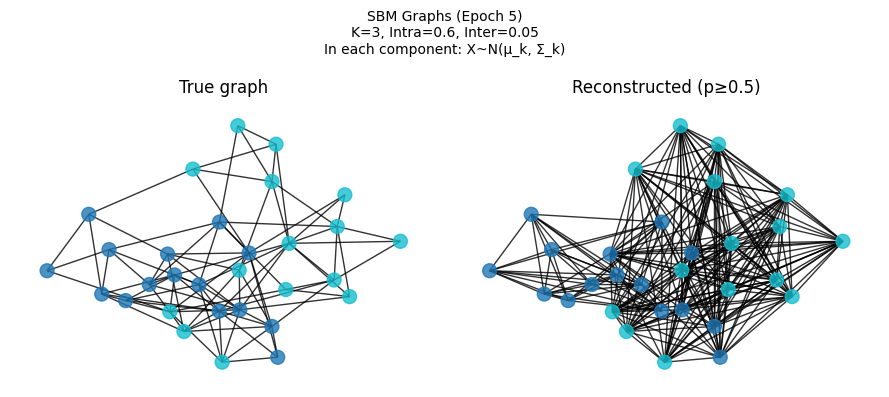

Epoch 006 | Loss: 21155.07 | Recon: 21142.43 | KL: 1052.73 | kl_w: 0.0120
Epoch 007 | Loss: 20176.66 | Recon: 20164.28 | KL: 884.43 | kl_w: 0.0140
Epoch 008 | Loss: 19522.46 | Recon: 19503.53 | KL: 1183.10 | kl_w: 0.0160
Epoch 009 | Loss: 18468.86 | Recon: 18453.10 | KL: 875.14 | kl_w: 0.0180
Epoch 010 | Loss: 17941.18 | Recon: 17929.36 | KL: 591.11 | kl_w: 0.0200


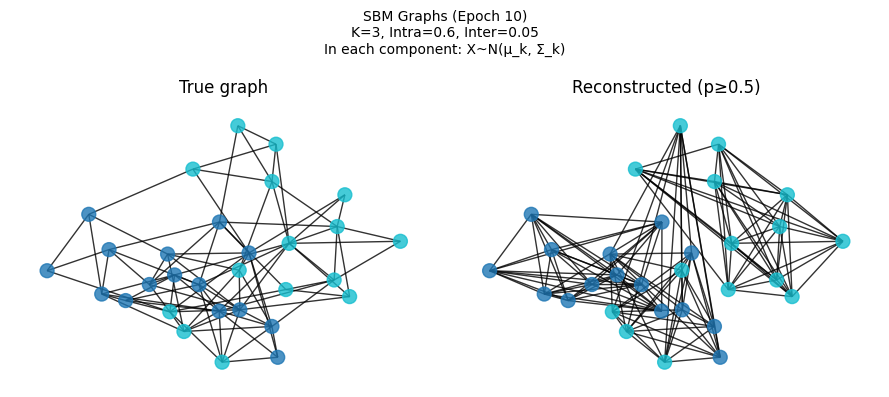

Epoch 011 | Loss: 17833.45 | Recon: 17823.04 | KL: 473.24 | kl_w: 0.0220
Epoch 012 | Loss: 17780.10 | Recon: 17769.95 | KL: 423.10 | kl_w: 0.0240
Epoch 013 | Loss: 17713.95 | Recon: 17703.41 | KL: 405.67 | kl_w: 0.0260
Epoch 014 | Loss: 17746.84 | Recon: 17735.82 | KL: 393.62 | kl_w: 0.0280
Epoch 015 | Loss: 17727.12 | Recon: 17715.43 | KL: 389.59 | kl_w: 0.0300


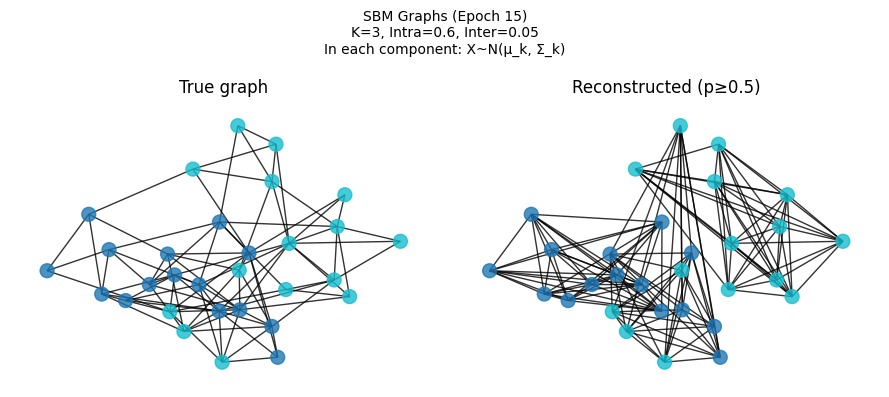

Epoch 016 | Loss: 17757.48 | Recon: 17744.78 | KL: 396.70 | kl_w: 0.0320
Epoch 017 | Loss: 17707.55 | Recon: 17694.12 | KL: 395.00 | kl_w: 0.0340
Epoch 018 | Loss: 17706.85 | Recon: 17692.93 | KL: 386.45 | kl_w: 0.0360
Epoch 019 | Loss: 17702.79 | Recon: 17687.94 | KL: 390.80 | kl_w: 0.0380
Epoch 020 | Loss: 17684.00 | Recon: 17668.24 | KL: 394.19 | kl_w: 0.0400


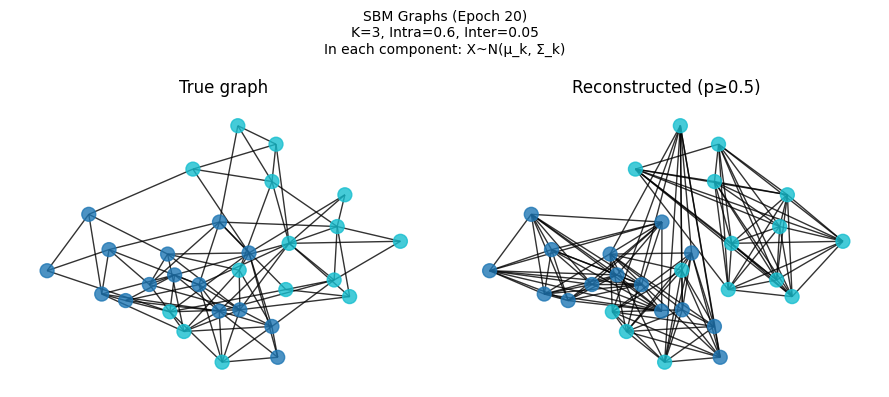

Epoch 021 | Loss: 17675.30 | Recon: 17658.60 | KL: 397.52 | kl_w: 0.0420
Epoch 022 | Loss: 17717.09 | Recon: 17698.93 | KL: 412.67 | kl_w: 0.0440
Epoch 023 | Loss: 17689.80 | Recon: 17672.16 | KL: 383.59 | kl_w: 0.0460
Epoch 024 | Loss: 17648.49 | Recon: 17630.85 | KL: 367.64 | kl_w: 0.0480
Epoch 025 | Loss: 17679.22 | Recon: 17660.95 | KL: 365.43 | kl_w: 0.0500


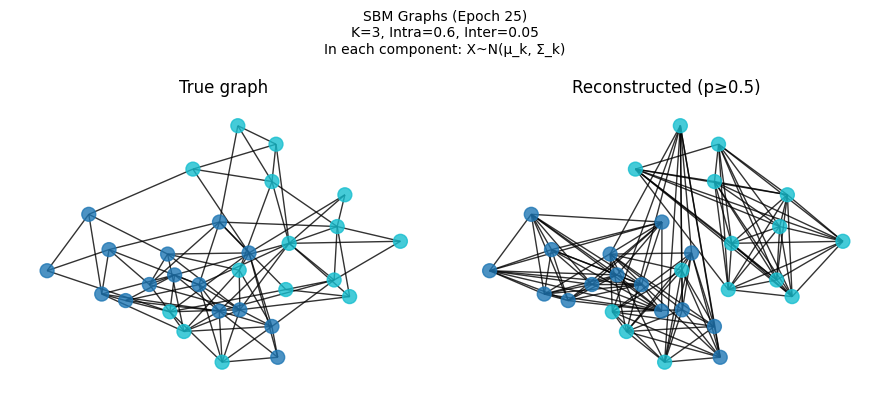

Epoch 026 | Loss: 17631.00 | Recon: 17612.18 | KL: 361.91 | kl_w: 0.0520
Epoch 027 | Loss: 17667.54 | Recon: 17648.07 | KL: 360.43 | kl_w: 0.0540
Epoch 028 | Loss: 17643.51 | Recon: 17623.13 | KL: 363.85 | kl_w: 0.0560
Epoch 029 | Loss: 17599.14 | Recon: 17577.58 | KL: 371.79 | kl_w: 0.0580
Epoch 030 | Loss: 17677.57 | Recon: 17654.23 | KL: 389.01 | kl_w: 0.0600


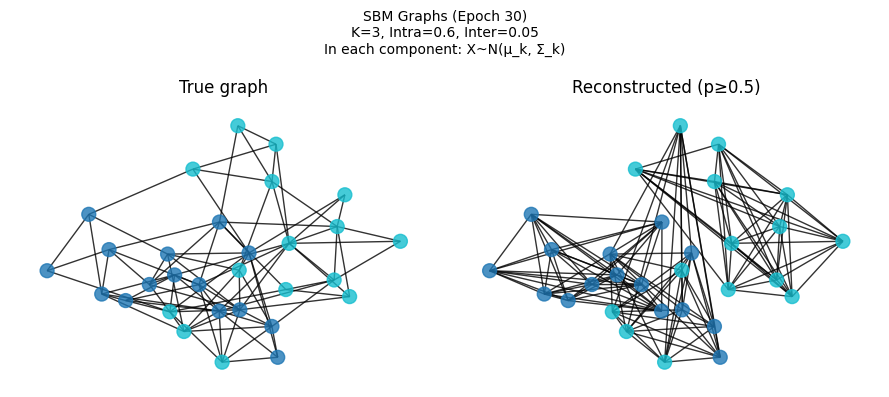

Epoch 031 | Loss: 17606.48 | Recon: 17584.86 | KL: 348.77 | kl_w: 0.0620
Epoch 032 | Loss: 17615.58 | Recon: 17594.36 | KL: 331.47 | kl_w: 0.0640
Epoch 033 | Loss: 17550.58 | Recon: 17528.53 | KL: 334.11 | kl_w: 0.0660
Epoch 034 | Loss: 17543.61 | Recon: 17521.49 | KL: 325.27 | kl_w: 0.0680
Epoch 035 | Loss: 17554.95 | Recon: 17532.34 | KL: 323.05 | kl_w: 0.0700


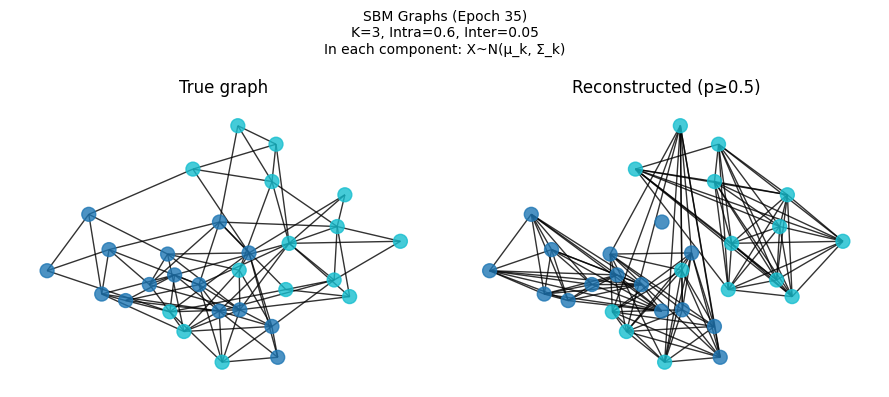

Epoch 036 | Loss: 17526.03 | Recon: 17503.22 | KL: 316.78 | kl_w: 0.0720
Epoch 037 | Loss: 17444.40 | Recon: 17421.73 | KL: 306.43 | kl_w: 0.0740
Epoch 038 | Loss: 17440.34 | Recon: 17417.30 | KL: 303.04 | kl_w: 0.0760
Epoch 039 | Loss: 17480.02 | Recon: 17454.98 | KL: 321.11 | kl_w: 0.0780
Epoch 040 | Loss: 17416.94 | Recon: 17393.55 | KL: 292.41 | kl_w: 0.0800


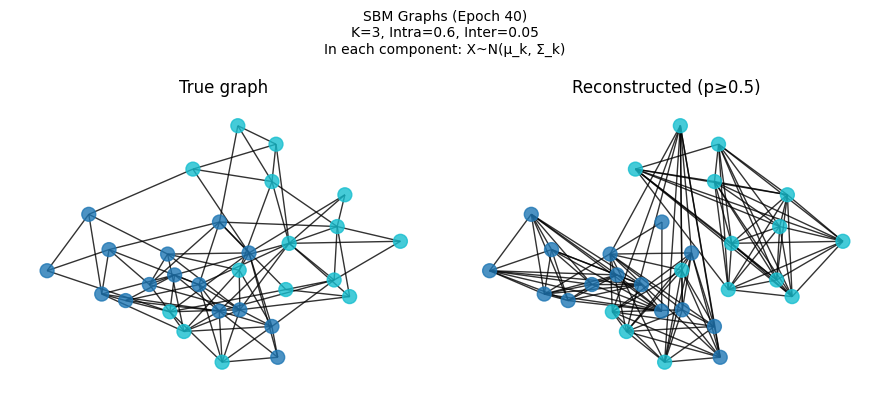

Epoch 041 | Loss: 17345.56 | Recon: 17322.76 | KL: 278.11 | kl_w: 0.0820
Epoch 042 | Loss: 17375.13 | Recon: 17351.32 | KL: 283.46 | kl_w: 0.0840
Epoch 043 | Loss: 17437.62 | Recon: 17412.90 | KL: 287.47 | kl_w: 0.0860
Epoch 044 | Loss: 17360.47 | Recon: 17336.95 | KL: 267.27 | kl_w: 0.0880
Epoch 045 | Loss: 17291.97 | Recon: 17266.79 | KL: 279.78 | kl_w: 0.0900


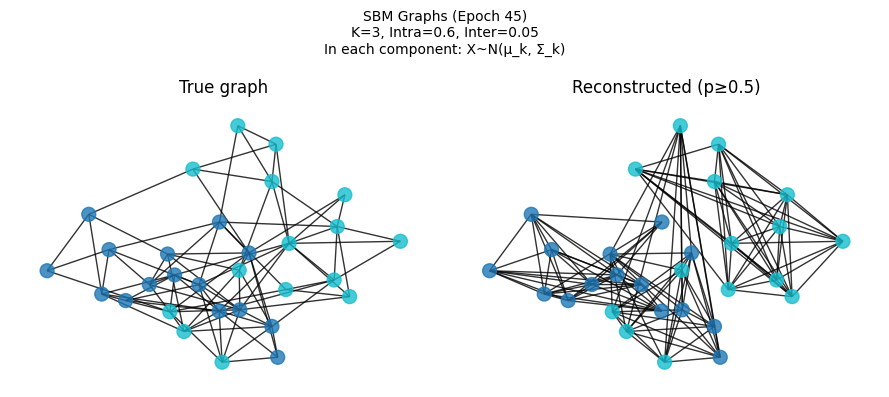

Epoch 046 | Loss: 17319.84 | Recon: 17295.21 | KL: 267.73 | kl_w: 0.0920
Epoch 047 | Loss: 17249.28 | Recon: 17226.10 | KL: 246.50 | kl_w: 0.0940
Epoch 048 | Loss: 17215.35 | Recon: 17192.42 | KL: 238.85 | kl_w: 0.0960
Epoch 049 | Loss: 17165.21 | Recon: 17142.07 | KL: 236.12 | kl_w: 0.0980
Epoch 050 | Loss: 17183.63 | Recon: 17159.99 | KL: 236.35 | kl_w: 0.1000


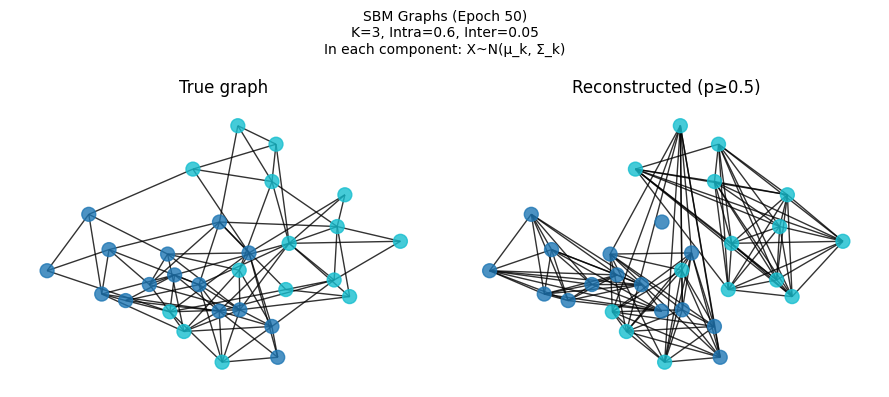

Epoch 051 | Loss: 17141.25 | Recon: 17119.32 | KL: 219.34 | kl_w: 0.1000
Epoch 052 | Loss: 17119.72 | Recon: 17098.48 | KL: 212.45 | kl_w: 0.1000
Epoch 053 | Loss: 17131.01 | Recon: 17109.20 | KL: 218.13 | kl_w: 0.1000
Epoch 054 | Loss: 17043.89 | Recon: 17023.14 | KL: 207.46 | kl_w: 0.1000
Epoch 055 | Loss: 16985.31 | Recon: 16965.08 | KL: 202.37 | kl_w: 0.1000


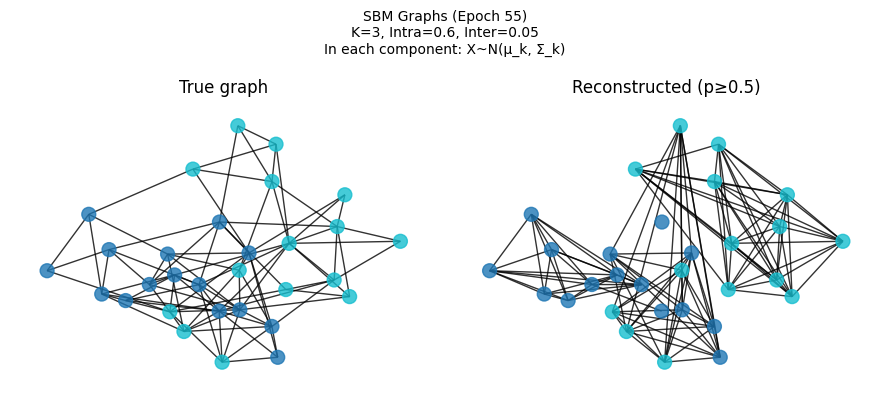

Epoch 056 | Loss: 16963.48 | Recon: 16943.30 | KL: 201.79 | kl_w: 0.1000
Epoch 057 | Loss: 16991.67 | Recon: 16971.25 | KL: 204.16 | kl_w: 0.1000
Epoch 058 | Loss: 16979.92 | Recon: 16957.99 | KL: 219.28 | kl_w: 0.1000
Epoch 059 | Loss: 16902.95 | Recon: 16879.47 | KL: 234.75 | kl_w: 0.1000
Epoch 060 | Loss: 16842.10 | Recon: 16821.05 | KL: 210.53 | kl_w: 0.1000


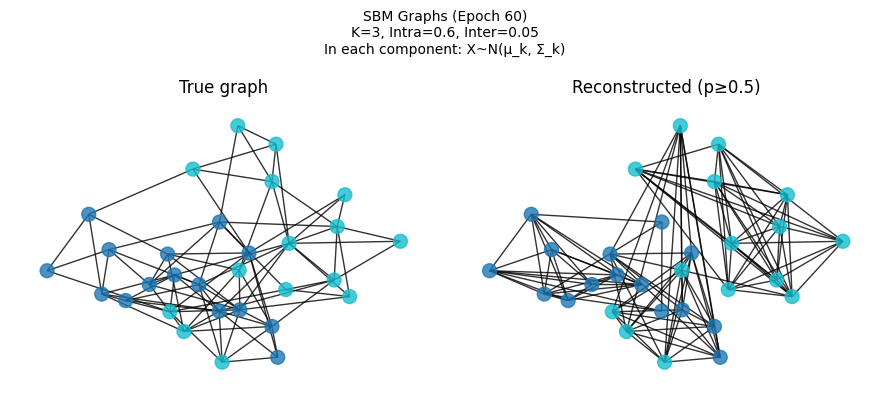

Epoch 061 | Loss: 16746.22 | Recon: 16726.45 | KL: 197.70 | kl_w: 0.1000
Epoch 062 | Loss: 16665.64 | Recon: 16645.44 | KL: 202.04 | kl_w: 0.1000
Epoch 063 | Loss: 16619.19 | Recon: 16598.93 | KL: 202.61 | kl_w: 0.1000
Epoch 064 | Loss: 16518.47 | Recon: 16498.93 | KL: 195.42 | kl_w: 0.1000
Epoch 065 | Loss: 16441.51 | Recon: 16422.39 | KL: 191.25 | kl_w: 0.1000


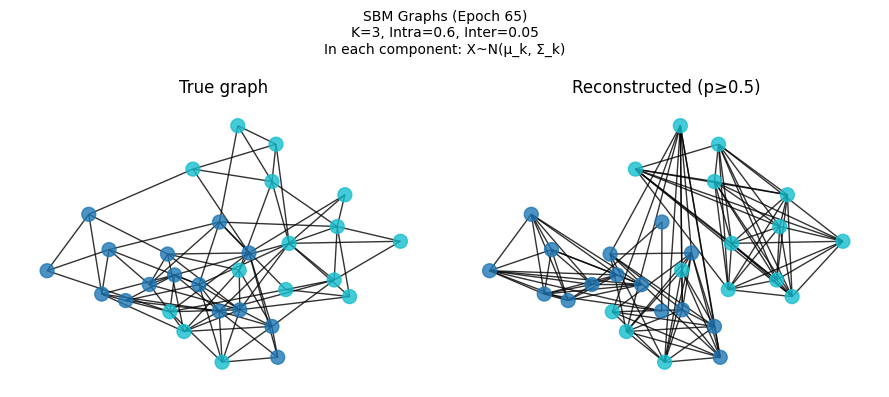

Epoch 066 | Loss: 16360.47 | Recon: 16341.79 | KL: 186.77 | kl_w: 0.1000
Epoch 067 | Loss: 16253.76 | Recon: 16235.00 | KL: 187.54 | kl_w: 0.1000
Epoch 068 | Loss: 16198.66 | Recon: 16179.51 | KL: 191.42 | kl_w: 0.1000
Epoch 069 | Loss: 16109.91 | Recon: 16091.52 | KL: 183.94 | kl_w: 0.1000
Epoch 070 | Loss: 16084.27 | Recon: 16065.41 | KL: 188.59 | kl_w: 0.1000


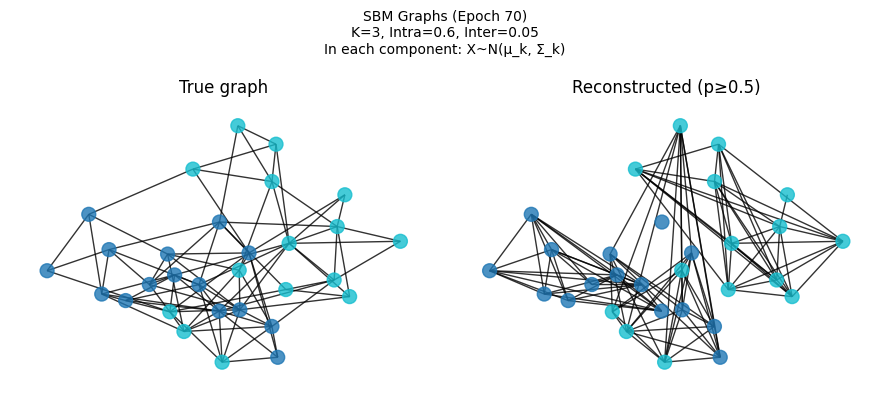

Epoch 071 | Loss: 16023.68 | Recon: 16004.64 | KL: 190.42 | kl_w: 0.1000
Epoch 072 | Loss: 15940.73 | Recon: 15919.16 | KL: 215.64 | kl_w: 0.1000
Epoch 073 | Loss: 15871.56 | Recon: 15851.86 | KL: 196.95 | kl_w: 0.1000
Epoch 074 | Loss: 15801.97 | Recon: 15782.45 | KL: 195.14 | kl_w: 0.1000
Epoch 075 | Loss: 15727.16 | Recon: 15708.20 | KL: 189.57 | kl_w: 0.1000


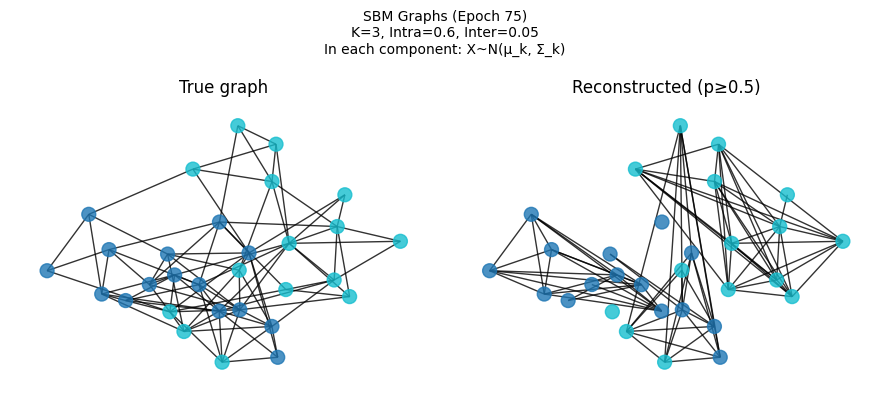

Epoch 076 | Loss: 15719.29 | Recon: 15698.68 | KL: 206.17 | kl_w: 0.1000
Epoch 077 | Loss: 15634.75 | Recon: 15614.45 | KL: 202.93 | kl_w: 0.1000
Epoch 078 | Loss: 15565.96 | Recon: 15546.34 | KL: 196.20 | kl_w: 0.1000
Epoch 079 | Loss: 15486.89 | Recon: 15467.90 | KL: 189.92 | kl_w: 0.1000
Epoch 080 | Loss: 15517.02 | Recon: 15497.27 | KL: 197.48 | kl_w: 0.1000


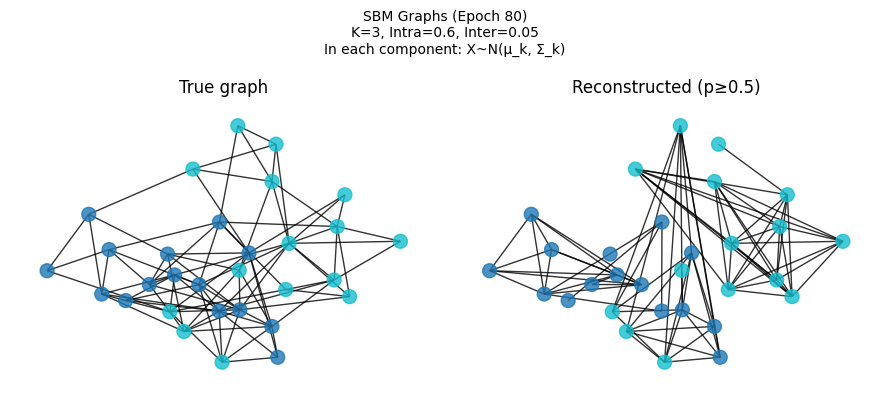

Epoch 081 | Loss: 15433.01 | Recon: 15412.61 | KL: 204.06 | kl_w: 0.1000
Epoch 082 | Loss: 15449.97 | Recon: 15429.03 | KL: 209.36 | kl_w: 0.1000
Epoch 083 | Loss: 15427.40 | Recon: 15405.23 | KL: 221.69 | kl_w: 0.1000
Epoch 084 | Loss: 15461.40 | Recon: 15438.74 | KL: 226.59 | kl_w: 0.1000
Epoch 085 | Loss: 15367.58 | Recon: 15346.31 | KL: 212.66 | kl_w: 0.1000


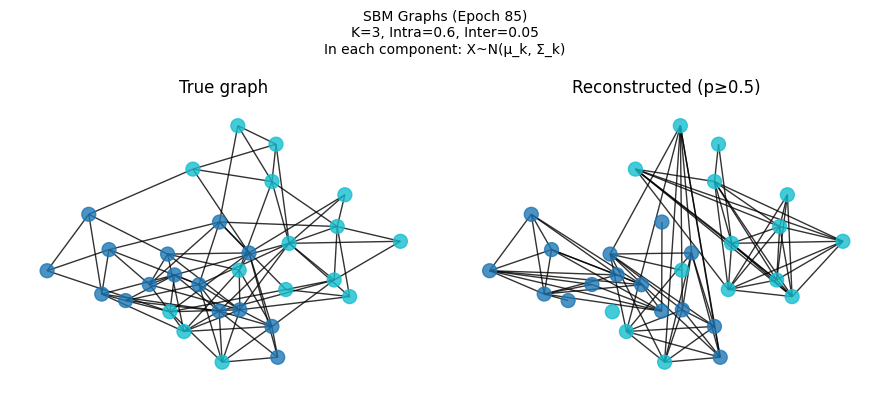

Epoch 086 | Loss: 15403.85 | Recon: 15383.19 | KL: 206.62 | kl_w: 0.1000
Epoch 087 | Loss: 15365.25 | Recon: 15346.25 | KL: 189.96 | kl_w: 0.1000
Epoch 088 | Loss: 15276.71 | Recon: 15257.19 | KL: 195.15 | kl_w: 0.1000
Epoch 089 | Loss: 15268.45 | Recon: 15249.02 | KL: 194.31 | kl_w: 0.1000
Epoch 090 | Loss: 15201.24 | Recon: 15181.05 | KL: 201.97 | kl_w: 0.1000


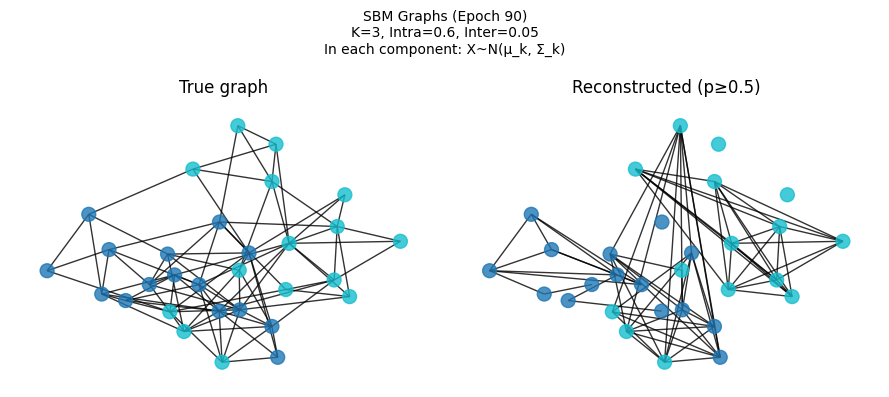

Epoch 091 | Loss: 15165.09 | Recon: 15146.36 | KL: 187.23 | kl_w: 0.1000
Epoch 092 | Loss: 15198.14 | Recon: 15179.39 | KL: 187.55 | kl_w: 0.1000
Epoch 093 | Loss: 15186.97 | Recon: 15166.94 | KL: 200.33 | kl_w: 0.1000
Epoch 094 | Loss: 15140.26 | Recon: 15118.55 | KL: 217.08 | kl_w: 0.1000
Epoch 095 | Loss: 15215.14 | Recon: 15190.97 | KL: 241.66 | kl_w: 0.1000


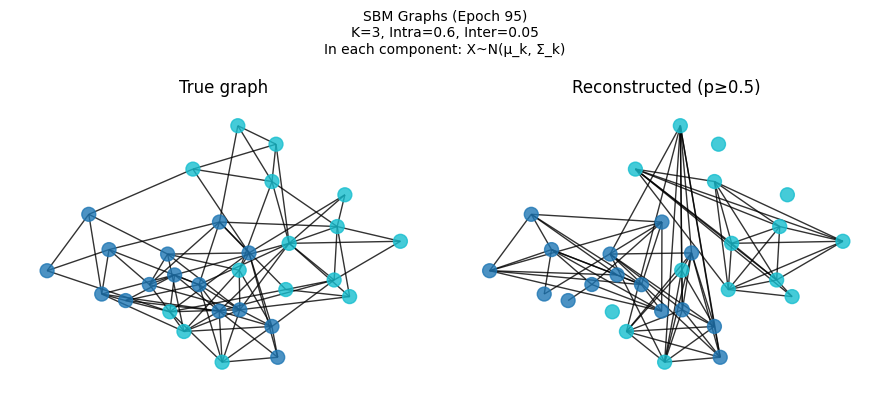

Epoch 096 | Loss: 15081.30 | Recon: 15059.50 | KL: 217.98 | kl_w: 0.1000
Epoch 097 | Loss: 15107.70 | Recon: 15086.48 | KL: 212.19 | kl_w: 0.1000
Epoch 098 | Loss: 15061.06 | Recon: 15041.34 | KL: 197.20 | kl_w: 0.1000
Epoch 099 | Loss: 15021.21 | Recon: 15000.16 | KL: 210.45 | kl_w: 0.1000
Epoch 100 | Loss: 15012.59 | Recon: 14990.82 | KL: 217.68 | kl_w: 0.1000


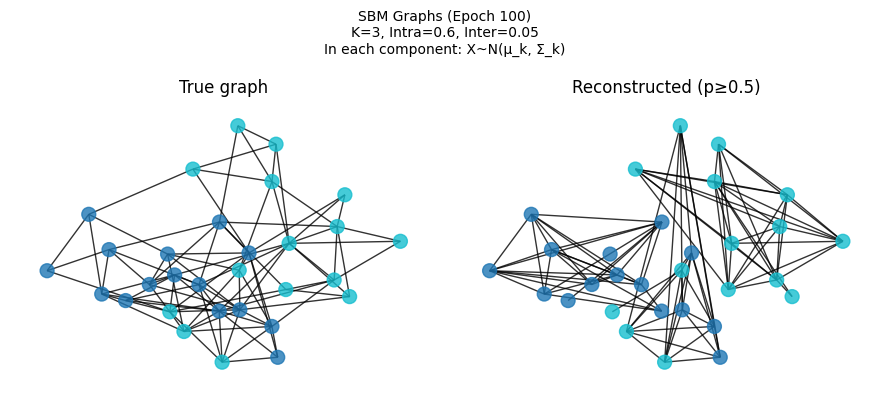

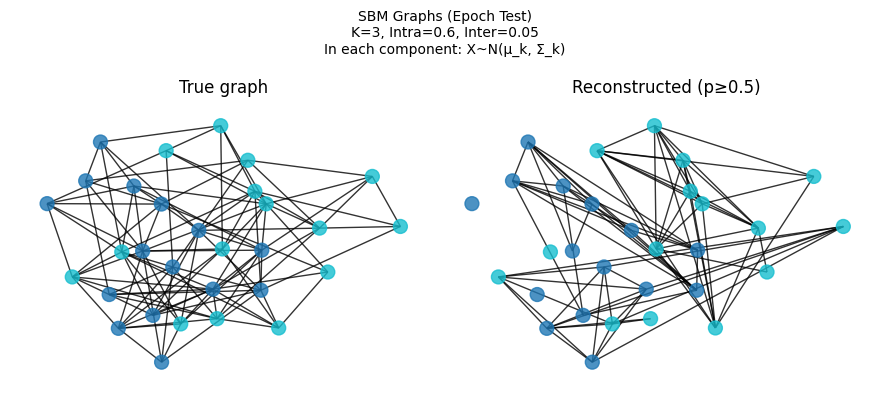

Test accuracy: 0.7387


In [41]:

if __name__ == "__main__":
    model, dataset = train_model(vis_interval=5, epochs=100)
    test_model(model, dataset)


# Question 2: Conditional Variational Autoencoder (CVAE) for Digit Generation

This note introduces a **Conditional Variational Autoencoder (CVAE)** for image generation on the **MNIST** dataset. The goal is to learn a deep latent-variable model that can synthesize digits conditioned on a desired label—e.g., generate a “2” on demand—and optionally modulate the writing style.


## **Problem setup**

We observe training pairs of handwritten digits and their class labels
$$
\mathcal{D} = {(x^{(i)}, y^{(i)})}_{i=1}^N,
$$
where $x^{(i)} \in \mathbb{R}^{28\times28}$ is an image and $y^{(i)} \in {0,\dots,9}$ is the corresponding digit label.
Our goal is to model the conditional data distribution
$$
p_\theta(x \mid y),
$$
so that, given any label $y$, the model can generate realistic samples $x$ of that digit.



100%|██████████| 9.91M/9.91M [00:00<00:00, 41.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.43MB/s]


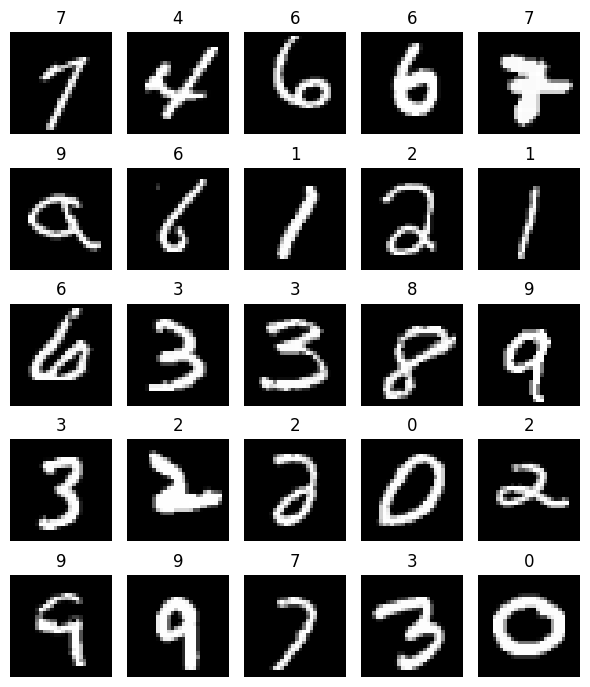

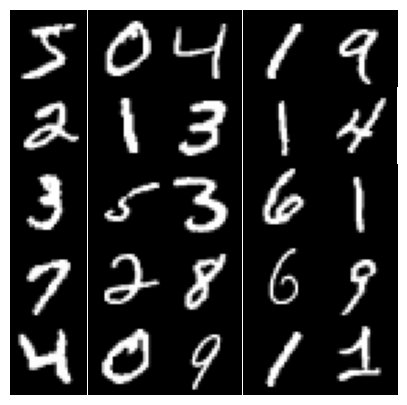

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
import matplotlib.pyplot as plt


def get_mnist_dataset(root: str = "./data", train: bool = True):
    """
    Load the MNIST dataset with a simple ToTensor transform.
    """
    transform = transforms.ToTensor()
    return datasets.MNIST(root=root, train=train, download=True, transform=transform)


def show_random_mnist_grid(dataset, n_rows: int = 5, n_cols: int = 5, figsize=(6, 7)):
    """
    Display a grid of random MNIST samples with their labels.

    Args:
        dataset : a torchvision MNIST dataset
        n_rows  : number of rows in the grid
        n_cols  : number of columns in the grid
        figsize : figure size passed to plt.subplots
    """
    num_images = n_rows * n_cols
    indices = torch.randperm(len(dataset))[:num_images]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

    for ax, idx in zip(axes.flat, indices):
        img, label = dataset[idx]          # img: [1, 28, 28]
        ax.imshow(img.view(28, 28), cmap="gray")
        ax.set_title(f"{label}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_results(images: torch.Tensor, n_rows: int = 5, n_cols: int = 5):
    """
    Visualize a batch of (at least n_rows * n_cols) images in a grid.

    Args:
        images : tensor of shape [B, 1, 28, 28] or [B, 28, 28]
        n_rows : number of rows in the grid
        n_cols : number of columns in the grid
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5, 5))

    num_images = n_rows * n_cols
    for i, ax in enumerate(axes.flat):
        if i >= num_images:
            break
        img = images[i]
        ax.imshow(img.view(28, 28).numpy(), cmap="gray")
        ax.axis("off")

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


if __name__ == "__main__":
    mnist_train = get_mnist_dataset()
    show_random_mnist_grid(mnist_train, n_rows=5, n_cols=5)

    # Example: visualize first 25 images from the dataset using visualize_results
    sample_images = torch.stack([mnist_train[i][0] for i in range(25)], dim=0)
    visualize_results(sample_images, n_rows=5, n_cols=5)


### **Model setup**

We introduce a latent variable $ z \in \mathbb{R}^m $ that captures continuous variations in handwriting style.
The joint distribution is defined as

$$
p_\theta(x, z \mid y) = p_\theta(x \mid z, y) p(z),
$$

where $ p(z) = \mathcal{N}(0, I) $ is a fixed Gaussian prior.

* **Decoder (generative model):** $ p_\theta(x \mid z, y) $ reconstructs the image given latent code $z$ and label $y$.
* **Encoder (inference model):** we approximate the true posterior $ p_\theta(z \mid x, y) $ with

$$
q_\phi(z \mid x, y) = \mathcal{N}\big(\mu_\phi(x, y), \mathrm{diag}(\sigma_\phi^2(x, y))\big).
$$



### **Derivation of the Conditional ELBO**

Our goal is to maximize the conditional log-likelihood of the data:

$$
\log p_\theta(x \mid y).
$$

Since this is intractable, we derive a lower bound (the **conditional ELBO**):

$$
\log p_\theta(x \mid y)
\ge
\mathbb{E}_{q_\phi(z \mid x, y)}[\log p_\theta(x \mid z, y)]

D_{\mathrm{KL}}\big(q_\phi(z \mid x, y) | p(z)\big).
$$

### **Training objective**

The right-hand side is the objective we actually optimize.
We **maximize** the ELBO with respect to parameters $\theta$ and $\phi$, or equivalently, **minimize** the negative ELBO (which is used as the loss in code):

$$
\mathcal{L}_{\text{CVAE}}(x, y)
= -\mathbb{E}_{q_\phi(z \mid x, y)}[\log p_\theta(x \mid z, y)]
+ D_{\mathrm{KL}}\big(q_\phi(z \mid x, y) | p(z)\big).
$$

- The first term (reconstruction loss) ensures that decoded samples resemble the input image.
- The second term (KL divergence) regularizes the latent distribution so that it stays close to the Gaussian prior, which keeps sampling stable during generation.




In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------------------------------------------------------
# Encoder
# ---------------------------------------------------------------------------

class Encoder(nn.Module):
    """
    Conditional encoder q(z | x, y).
    Inputs:
      - x: flattened image, shape [B, 784]
      - y: one-hot labels, shape [B, y_dim]
    Outputs:
      - mu, logvar: [B, z_dim]
    """

    def __init__(self, y_dim: int, z_dim: int):
        super().__init__()

        input_dim = 784 + y_dim
        hidden_dims = [1024, 512, 256]

        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout(p=0.1),
            ])
            in_dim = h_dim

        self.backbone = nn.Sequential(*layers)

        self.mu_head = nn.Linear(hidden_dims[-1], z_dim)
        self.logvar_head = nn.Linear(hidden_dims[-1], z_dim)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        """
        Args:
            x: [B, 784]
            y: [B, y_dim] (already one-hot)

        Returns:
            mu, logvar: [B, z_dim]
        """
        xy = torch.cat([x, y], dim=1)      # [B, 784 + y_dim]
        h = self.backbone(xy)              # [B, hidden]
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar


# ---------------------------------------------------------------------------
# Decoder
# ---------------------------------------------------------------------------

class Decoder(nn.Module):
    """
    Conditional decoder p(x | z, y).
    Inputs:
      - z: latent sample, shape [B, z_dim]
      - y: one-hot labels, shape [B, y_dim]
    Output:
      - reconstruction x_hat: [B, 784] in [0, 1] (via Sigmoid)
    """

    def __init__(self, y_dim: int, z_dim: int):
        super().__init__()

        input_dim = z_dim + y_dim
        hidden_dims = [256, 512, 1024]

        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout(p=0.1),
            ])
            in_dim = h_dim

        # Final layer to 784 pixels
        layers.extend([
            nn.Linear(hidden_dims[-1], 784),
            nn.Sigmoid(),   # output in [0, 1]
        ])

        self.backbone = nn.Sequential(*layers)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, z: torch.Tensor, y: torch.Tensor):
        """
        Args:
            z: [B, z_dim]
            y: [B, y_dim]

        Returns:
            x_recon: [B, 784] in [0, 1]
        """
        zy = torch.cat([z, y], dim=1)      # [B, z_dim + y_dim]
        x_recon = self.backbone(zy)
        return x_recon


# ---------------------------------------------------------------------------
# CVAE Wrapper
# ---------------------------------------------------------------------------

class CVAE(nn.Module):
    """
    Simple conditional VAE for MNIST.
    - y_dim: number of classes (10 for MNIST)
    - z_dim: latent dimension
    """

    def __init__(self, y_dim: int = 10, z_dim: int = 32):
        super().__init__()
        self.y_dim = y_dim
        self.encoder = Encoder(y_dim=y_dim, z_dim=z_dim)
        self.decoder = Decoder(y_dim=y_dim, z_dim=z_dim)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """
        Reparameterization trick:
            z = mu + std * eps,   eps ~ N(0, I)
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        """
        Args:
            x: [B, 1, 28, 28] images
            y: [B] (class indices) or [B, y_dim] (one-hot)

        Returns:
            x_recon: [B, 784]
            mu     : [B, z_dim]
            logvar : [B, z_dim]
        """
        # Flatten images
        x_flat = x.view(x.size(0), -1)  # [B, 784]

        # Ensure one-hot labels
        if y.dim() == 1:
            y_onehot = F.one_hot(y, num_classes=self.y_dim).float()
        else:
            y_onehot = y.float()

        mu, logvar = self.encoder(x_flat, y_onehot)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z, y_onehot)

        return x_recon, mu, logvar


In [4]:
# loss
def loss_function(x_recon, x, mu, logvar):
    # reconstruction loss (binary cross-entropy)
    recon_loss = F.binary_cross_entropy(x_recon, x.view(-1, 784), reduction='sum')

    # KL divergence between q(z|x,y) and N(0,I)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss, recon_loss, kl_loss

In [5]:
# training
# dataloader
batch_size = 128
train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor()), batch_size=batch_size, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(y_dim=10, z_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 150
### don't edit this !!!
for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(x, y)

        loss, recon_loss, kl_loss = loss_function(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    n = len(train_loader.dataset)
    print(f"Epoch {epoch:02d}  Loss per example: {total_loss / n:.4f}  Recon: {total_recon / n:.4f}  KL: {total_kl / n:.4f}")


Epoch 01  Loss per example: 143.9734  Recon: 125.2826  KL: 18.6909
Epoch 02  Loss per example: 120.0548  Recon: 101.1283  KL: 18.9265
Epoch 03  Loss per example: 115.2703  Recon: 96.3321  KL: 18.9382
Epoch 04  Loss per example: 112.8813  Recon: 93.9572  KL: 18.9241
Epoch 05  Loss per example: 111.4601  Recon: 92.5785  KL: 18.8816
Epoch 06  Loss per example: 110.4529  Recon: 91.5620  KL: 18.8909
Epoch 07  Loss per example: 109.5854  Recon: 90.6714  KL: 18.9140
Epoch 08  Loss per example: 108.9664  Recon: 90.0531  KL: 18.9134
Epoch 09  Loss per example: 108.3593  Recon: 89.4683  KL: 18.8910
Epoch 10  Loss per example: 107.9503  Recon: 89.0528  KL: 18.8975
Epoch 11  Loss per example: 107.5084  Recon: 88.5708  KL: 18.9376
Epoch 12  Loss per example: 107.1943  Recon: 88.2945  KL: 18.8998
Epoch 13  Loss per example: 106.8145  Recon: 87.8761  KL: 18.9384
Epoch 14  Loss per example: 106.6571  Recon: 87.6936  KL: 18.9635
Epoch 15  Loss per example: 106.3747  Recon: 87.4194  KL: 18.9553
Epoch 16

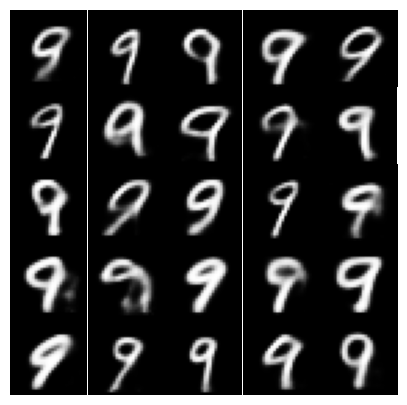

In [6]:
# model inferencing
model.eval()
with torch.no_grad():
    # choose the digit you want to generate
    digit = 9  # for example, "2"
    n = 25
    y = F.one_hot(torch.tensor([digit] * n).to(device), num_classes=10).float()

    # match the latent size to your model (z_dim=32)
    z = torch.randn(n, 32).to(device)

    # decode to images
    x_gen = model.decoder(z, y).cpu()

# visualize
visualize_results(x_gen)

### Student ID Generation
After training your CVAE model, define a function that takes your 9-digit student ID as input and generates one digit per number in your ID. Each digit must be conditioned on its corresponding label (0–9). Arrange the generated digits horizontally in a 1×9 grid to visually display your complete student ID as a sequence of generated MNIST-style digits. Include this final generated image in your report.

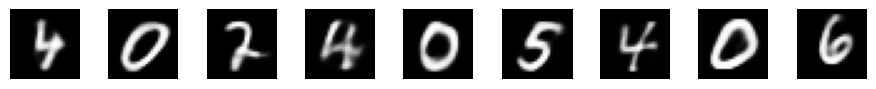

In [8]:
def generate_student_digits(model, student_id, device='cpu'):
    """
    Generate and display one digit image per digit in `student_id`
    using a trained CVAE decoder.

    Args:
        model      : trained CVAE model
        student_id : int or str, e.g. 123456
        device     : 'cpu' or 'cuda' (string, kept for compatibility)
    """
    model.eval()
    device = torch.device(device)

    # ------------------------------------------------------------------
    # Prepare conditional labels from student_id digits
    # ------------------------------------------------------------------
    digits_str = str(student_id)
    digits = [int(d) for d in digits_str]   # assumes all chars are digits
    n = len(digits)

    y_idx = torch.tensor(digits, device=device)                 # [n]
    y_onehot = F.one_hot(y_idx, num_classes=10).float()         # [n, 10]

    # ------------------------------------------------------------------
    # Sample latent codes and decode
    # ------------------------------------------------------------------
    # z_dim is 32 as used during training
    z = torch.randn(n, 32, device=device)                       # [n, 32]

    with torch.no_grad():
        x_gen = model.decoder(z, y_onehot).cpu()                # [n, 784]

    # ------------------------------------------------------------------
    # Visualization
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, n, figsize=(n, 1))

    # Make sure axes is iterable even when n == 1
    if n == 1:
        axes = (axes,)

    for i, ax in enumerate(axes):
        img = x_gen[i].view(28, 28).numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

generate_student_digits(model, 402405406, device)

### **Latent Space Exploration**
To demonstrate that your CVAE has learned a meaningful latent representation, write a function that visualizes the latent space of the model.
Select **two random latent directions** in $z$-space, fix a target digit label $y$, and generate a **9×9 grid** of samples by varying these two directions from negative to positive values.
The center of the grid should correspond to $z = 0$ (the mean latent vector), while moving along the axes explores different variations of handwriting style.
After visualizing, **describe what each direction appears to represent**—for example, changes in stroke thickness, slant, or digit shape—and discuss whether the transformations look smooth and interpretable.


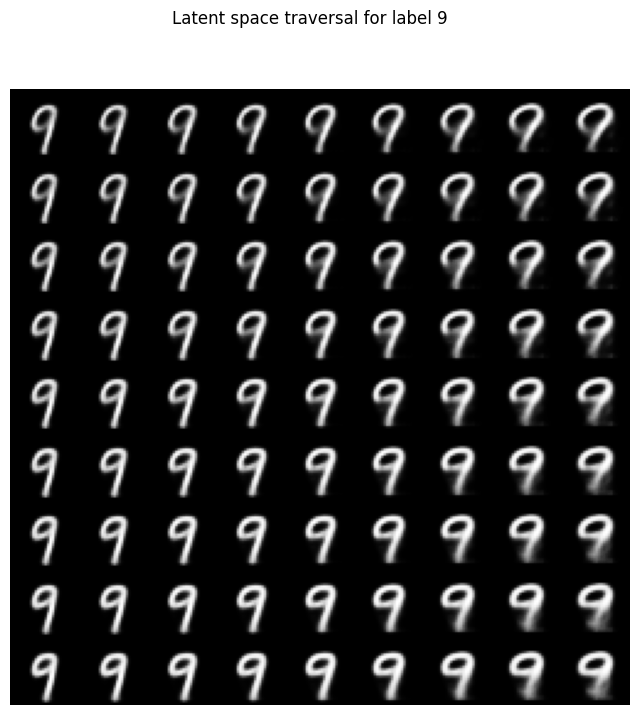

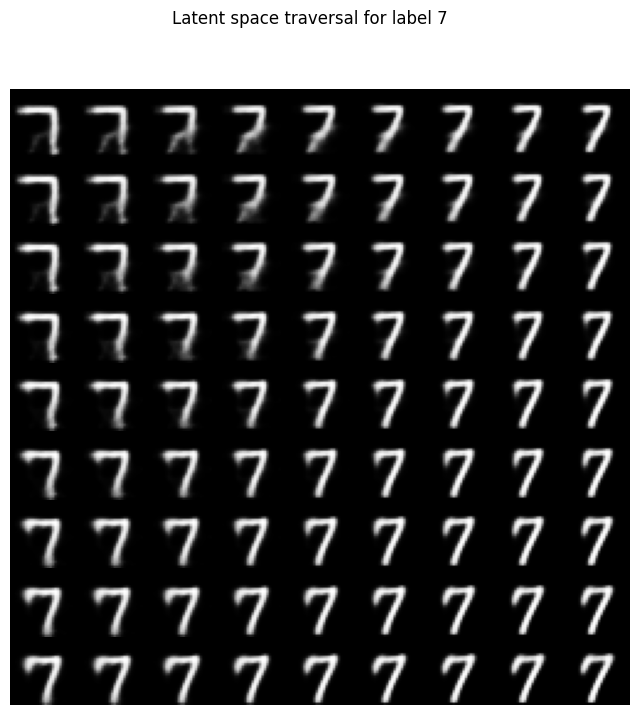

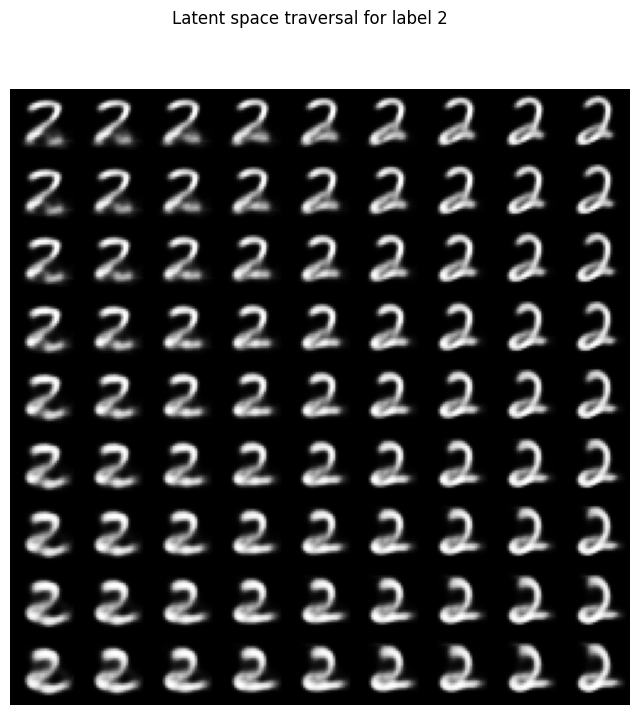

In [9]:
def visualize_latent_space(model, y_label, z_dim=32, grid_size=9, scale=2.0, device='cpu'):
    """
    Visualize a 2D slice of the latent space for a fixed class label.

    We:
      - Sample two random directions v1, v2 in latent space.
      - Create a grid of latent points in the plane spanned by v1 and v2.
      - Decode all points with the same label y_label.
      - Plot the resulting images in a grid.

    Args:
        model      : trained CVAE model with a .decoder(z, y) method
        y_label    : int, class label to condition on (0–9 for MNIST)
        z_dim      : latent dimensionality (default 32)
        grid_size  : number of points per axis (grid_size x grid_size)
        scale      : extent of the traversal along each direction
        device     : 'cpu' or 'cuda' (string, kept for compatibility)
    """
    model.eval()
    device = torch.device(device)

    # ------------------------------------------------------------------
    # Sample two random orthogonal-ish directions in latent space
    # ------------------------------------------------------------------
    v1 = torch.randn(z_dim, device=device)
    v1 = v1 / v1.norm()

    v2 = torch.randn(z_dim, device=device)
    v2 = v2 / v2.norm()

    # ------------------------------------------------------------------
    # Build grid of latent points in span{v1, v2}
    # ------------------------------------------------------------------
    lin = torch.linspace(-scale, scale, grid_size, device=device)
    z_list = []

    for y_val in lin:
        for x_val in lin:
            z_vec = x_val * v1 + y_val * v2   # [z_dim]
            z_list.append(z_vec)

    z = torch.stack(z_list, dim=0)           # [grid_size^2, z_dim]

    # ------------------------------------------------------------------
    # Build label tensor (all same label y_label)
    # ------------------------------------------------------------------
    y_idx = torch.full((z.size(0),), int(y_label), device=device)
    y_onehot = F.one_hot(y_idx, num_classes=10).float()  # [grid_size^2, 10]

    # ------------------------------------------------------------------
    # Decode all latent points
    # ------------------------------------------------------------------
    with torch.no_grad():
        x_gen = model.decoder(z, y_onehot).cpu()         # [grid_size^2, 784]

    # ------------------------------------------------------------------
    # Plot grid of generated digits
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
    plt.suptitle(f"Latent space traversal for label {y_label}")

    for i, ax in enumerate(axes.flat):
        img = x_gen[i].view(28, 28).numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


visualize_latent_space(model, 9, device=device)
visualize_latent_space(model, 7, device=device)
visualize_latent_space(model, 2, device=device)



### **Bonus – Style-Controlled Student ID Generation**
Extend your CVAE to allow **style control** along a latent dimension.
Write a function that takes your **9-digit student ID** as input and generates one digit per number, arranged in a single row.
Additionally, for each digit, gradually vary the “style” dimension from thin to thick (or light to bold) as you move across the row, so that the same digit shows different styles.
Include the resulting image in your report and briefly describe how the style changes are reflected in the generated digits.


1. **Label conditioning:** We fix the digit identity by converting the student ID digits into one-hot label vectors $y_k$ so that only style, not class, changes when we move in latent space.

2. **Direction :** We sample random latent codes $z_i$ and labels $y_i$, decode them to images $x_i$, compute a thickness proxy $m_i = \sum_p x_i^{(p)}$, and obtain a style direction $d \propto \sum_i (m_i - \bar m)\, z_i$ in latent space.

3. **Style traversal:** For each digit position $k$ we construct latent codes $z_k = \alpha_k d$ with scalars $\alpha_k$ linearly spaced in $[-2.5, 2.5]$, thereby moving smoothly along the discovered style direction.

4. **Decoding and visualization:** We decode each pair $(z_k, y_k)$ with the CVAE decoder to obtain images of the same digit but with varying stroke thickness, and display them as a styled sequence of the student ID.


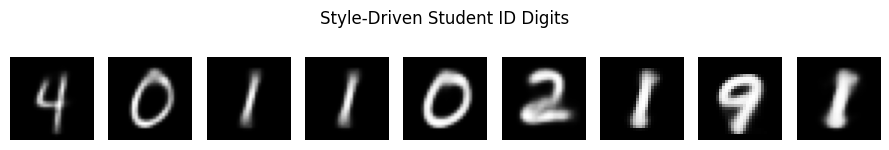

In [10]:
def generate_styled_student_digits(model, student_id, device='cpu'):
    """
    Generate a row of digits corresponding to the digits in `student_id`,
    with a smooth change in "style" controlled by a learned latent direction.

    Args:
        model      : trained CVAE model with .decoder(z, y)
        student_id : int or str (each character must be a digit)
        device     : 'cpu' or 'cuda'
    """
    model.eval()
    device = torch.device(device)

    # ------------------------------------------------------------------
    # 1) Learn a "style direction" in latent space
    #    (correlated with total pixel mass of the decoded images)
    # ------------------------------------------------------------------
    with torch.no_grad():
        num_samples = 1000

        # Sample random latent codes and random labels
        z_samples = torch.randn(num_samples, 32, device=device)  # [S, z_dim]
        y_indices = torch.randint(0, 10, (num_samples,), device=device)
        y_onehot = F.one_hot(y_indices, num_classes=10).float()  # [S, 10]

        # Decode to images
        x_out = model.decoder(z_samples, y_onehot)               # [S, 784]

        # Total "mass" (sum of pixel intensities) per image
        pixel_mass = x_out.view(num_samples, -1).sum(dim=1)      # [S]

        # Center mass and compute a direction in z that aligns with it
        centered_mass = pixel_mass - pixel_mass.mean()           # [S]
        style_direction = (z_samples.T @ centered_mass.unsqueeze(1)).squeeze()  # [32]

        # Normalize direction to unit length
        style_direction = style_direction / (style_direction.norm() + 1e-8)

    # ------------------------------------------------------------------
    # 2) Build label tensor from student_id and a 1D "style" trajectory
    # ------------------------------------------------------------------
    digits_str = str(student_id)
    digits = [int(d) for d in digits_str]
    n = len(digits)

    # One-hot labels for each digit
    y_indices = torch.tensor(digits, device=device)
    y_onehot = F.one_hot(y_indices, num_classes=10).float()      # [n, 10]

    # Sample points along the style direction (from -2.5 to +2.5)
    scales = torch.linspace(-2.5, 2.5, n, device=device)         # [n]
    z = torch.outer(scales, style_direction)                     # [n, 32]

    # ------------------------------------------------------------------
    # 3) Decode and visualize
    # ------------------------------------------------------------------
    with torch.no_grad():
        x_gen = model.decoder(z, y_onehot).cpu()                 # [n, 784]

    fig, axes = plt.subplots(1, n, figsize=(n, 1.5))
    plt.suptitle("Style-Driven Student ID Digits")

    # Make axes iterable even if n == 1
    if n == 1:
        axes = (axes,)

    for i, ax in enumerate(axes):
        img = x_gen[i].view(28, 28).numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
generate_styled_student_digits(model, 401102191, device)